 # TF-IDF Val/Test Drift Analysis



 Investigates whether val and test splits diverge in vocabulary/content —

 globally and per Additional Need (AN) category — as a possible explanation

 for Comprehend's val→test F1 collapse. Assumes note-level distributional

 stats (length, multi-need proportions, person coverage) have already been

 ruled out; this looks at text content itself.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)


 ## 1. Load data



 Expects a DataFrame per split with at minimum:

 - `note_id`

 - `text` (redacted/pseudonymised note text)

 - `an_categories` (list[str] of AN categories present in that note — for per-category analysis)

In [17]:
# --- Adjust paths to your actual val/test artifacts ---
train_df = pd.read_json("data/processed/train_data.json")
val_df = pd.read_json("data/processed/val_data.json")
test_df = pd.read_json("data/processed/test_data.json")

print(f"train: {len(train_df)}, val: {len(val_df)} notes, test: {len(test_df)} notes")


train: 1422, val: 288 notes, test: 290 notes


 ## 2. Global TF-IDF vocabulary drift



 Fit TF-IDF jointly (shared vocabulary) so both splits are comparable on

 the same feature space, then compare aggregate vectors and check

 out-of-vocabulary behaviour split-to-split.

In [3]:
# Fit vectorizer strictly on train
vectorizer = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2), min_df=3, stop_words="english"
)
train_tfidf = vectorizer.fit_transform(train_df["text"])
val_tfidf = vectorizer.transform(val_df["text"])
test_tfidf = vectorizer.transform(test_df["text"])

train_vocab = set(vectorizer.vocabulary_.keys())

# Measure OOV relative to what the model was trained on
val_vec_tmp = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2), min_df=3, stop_words="english"
).fit(val_df["text"])
test_vec_tmp = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2), min_df=3, stop_words="english"
).fit(test_df["text"])

val_oov = len(set(val_vec_tmp.vocabulary_.keys()) - train_vocab) / len(
    val_vec_tmp.vocabulary_
)
test_oov = len(set(test_vec_tmp.vocabulary_.keys()) - train_vocab) / len(
    test_vec_tmp.vocabulary_
)

print(f"Val OOV (unseen in Train): {val_oov:.2%}")
print(f"Test OOV (unseen in Train): {test_oov:.2%}")

Val OOV (unseen in Train): 5.06%
Test OOV (unseen in Train): 9.58%


In [4]:
# Mean TF-IDF vector cosine similarity (aggregate corpus-level comparison)
train_centroid = np.asarray(train_tfidf.mean(axis=0))
val_centroid = np.asarray(val_tfidf.mean(axis=0))
test_centroid = np.asarray(test_tfidf.mean(axis=0))

print(
    "Train vs Val Similarity:",
    cosine_similarity(train_centroid, val_centroid)[0][0],
)
print(
    "Train vs Test Similarity:",
    cosine_similarity(train_centroid, test_centroid)[0][0],
)
print(
    "Val vs Test Similarity:",
    cosine_similarity(val_centroid, test_centroid)[0][0],
)


Train vs Val Similarity: 0.9401284445358592
Train vs Test Similarity: 0.9393476465548829
Val vs Test Similarity: 0.9027729033390106


 ## 4. N-gram frequency diff (chi-squared)



 Cheap sanity check: which terms are disproportionately common in one

 split using raw counts and a chi-squared / log-likelihood style test,

 rather than TF-IDF weighting.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, stop_words="english")
val_counts = count_vec.fit_transform(val_df["text"]).sum(axis=0)
test_counts = count_vec.transform(test_df["text"]).sum(axis=0)

terms = count_vec.get_feature_names_out()
val_counts = np.asarray(val_counts).flatten()
test_counts = np.asarray(test_counts).flatten()

val_total = val_counts.sum()
test_total = test_counts.sum()

results = []
for term, vc, tc in zip(terms, val_counts, test_counts):
    if vc + tc < 10:
        continue
    table = np.array([[vc, val_total - vc], [tc, test_total - tc]])
    try:
        chi2, p, _, _ = chi2_contingency(table)
    except ValueError:
        continue
    results.append((term, vc, tc, chi2, p))

drift_df = pd.DataFrame(results, columns=["term", "val_count", "test_count", "chi2", "p_value"])
drift_df = drift_df.sort_values("chi2", ascending=False)
drift_df.head(30)


,term,val_count,test_count,chi2,p_value
392,stated,32,71,14.846449,0.000117
271,medical,43,17,9.974106,0.001588
465,window,14,1,9.378691,0.002195
109,court,13,31,6.917212,0.008537
146,email sent,11,28,6.891445,0.008661
400,summary,32,13,6.874842,0.008742
305,open,17,4,6.636064,0.009993
142,edward,11,1,6.582594,0.010298
81,charges summary,11,1,6.582594,0.010298
153,erica,13,2,6.481255,0.010902


 ## 5. Per-category TF-IDF centroid comparison



 The more diagnostic piece: since the F1 collapse is per-category (macro

 average), compute a TF-IDF centroid for notes containing each AN category

 in val vs test, and compare. Categories with low similarity are candidates

 for driving the collapse.

In [18]:
def category_centroid(df, tfidf_matrix, category, cat_col="needs"):
    # Check if category exists in any dict's 'label' key within the row's list
    mask = df[cat_col].apply(
        lambda cats: isinstance(cats, list)
        and any(
            isinstance(item, dict) and item.get("label") == category
            for item in cats
        )
    )
    if not mask.any():
        return None, 0

    centroid = np.asarray(tfidf_matrix[mask.values].mean(axis=0))
    return centroid, mask.sum()

all_categories = sorted(
    {
        item["label"]
        for df in [train_df, val_df, test_df]
        for needs_list in df["needs"].dropna()
        for item in needs_list
        if isinstance(item, dict) and "label" in item
    }
)

category_results = []
for cat in all_categories:
    train_c, train_n = category_centroid(train_df, train_tfidf, cat)
    val_c, val_n = category_centroid(val_df, val_tfidf, cat)
    test_c, test_n = category_centroid(test_df, test_tfidf, cat)

    if train_c is None or test_c is None:
        continue

    category_results.append({
        "category": cat,
        "train_n": train_n,
        "val_n": val_n,
        "test_n": test_n,
        "train_val_sim": (
            cosine_similarity(train_c, val_c)[0][0]
            if val_c is not None
            else None
        ),
        "train_test_sim": cosine_similarity(train_c, test_c)[0][0],
        "val_test_sim": (
            cosine_similarity(val_c, test_c)[0][0]
            if val_c is not None
            else None
        ),
    })

three_way_drift_df = pd.DataFrame(category_results).sort_values(
    "train_test_sim"
)
three_way_drift_df

,category,train_n,val_n,test_n,train_val_sim,train_test_sim,val_test_sim
7,communication_digital_exclusion,23,4,5,0.238899,0.314793,0.119189
10,disability_sensory,41,8,8,0.408021,0.372940,0.258434
25,property_level_infestation,36,7,7,0.489723,0.413819,0.343555
0,care_care_setting,29,6,5,0.455244,0.434706,0.420388
8,communication_fluency_in_english,34,7,7,0.496710,0.435145,0.315936
11,health_breathing_respiratory_problems,43,9,9,0.479112,0.439712,0.328593
30,safety_risk_firerelated_risks,52,11,12,0.467743,0.446205,0.322938
13,health_cognitive_impairment,45,10,9,0.451347,0.463236,0.308583
1,care_has_caring_responsibility,50,11,10,0.374550,0.465921,0.287549
4,cautions_physical_abuse_or_threat_of,47,10,10,0.501094,0.466517,0.332058


 ## 6. Cross-reference with Comprehend's per-category F1 drop



 Paste in per-category strict F1 (val, test) from your existing eval

 output. This lets you directly check whether low cosine similarity

 correlates with the categories where Comprehend's F1 collapsed hardest.

In [9]:
# Load validation and test metric CSVs
comprehend_f1_val = pd.read_csv(
    "data/results/val/metrics/span_comparison_per_label.csv"
)[["Label", "comprehend"]]
comprehend_f1_test = pd.read_csv(
    "data/results/metrics/span_comparison_per_label.csv"
)[["Label", "comprehend"]]

# Rename and merge validation + test metrics onto 'category'
comprehend_f1 = comprehend_f1_val.rename(
    columns={"Label": "category", "comprehend": "val_f1"}
).merge(
    comprehend_f1_test.rename(
        columns={"Label": "category", "comprehend": "test_f1"}
    ),
    on="category",
    how="inner",
)

# Compute performance drop
comprehend_f1["f1_drop"] = comprehend_f1["val_f1"] - comprehend_f1["test_f1"]

# Merge semantic category drift with performance metrics
merged = three_way_drift_df.merge(comprehend_f1, on="category", how="inner")
merged = merged.sort_values("f1_drop", ascending=False)
merged

,category,train_n,val_n,test_n,train_val_sim,train_test_sim,val_test_sim,val_f1,test_f1,f1_drop
8,care_has_caring_responsibility,50,11,10,0.374550,0.465921,0.287549,0.800000,0.315789,0.484211
11,health_terminally_ill,47,12,9,0.490995,0.480588,0.360136,0.787879,0.363636,0.424242
13,property_level_property_adapted,37,8,8,0.466069,0.490315,0.323996,0.700000,0.296296,0.403704
9,cautions_physical_abuse_or_threat_of,47,10,10,0.501094,0.466517,0.332058,0.500000,0.100000,0.400000
14,safety_risk_risk_of_exploitation,72,14,15,0.524607,0.497209,0.335537,0.652174,0.255319,0.396855
1,disability_sensory,41,8,8,0.408021,0.372940,0.258434,0.941176,0.555556,0.385621
0,communication_digital_exclusion,23,4,5,0.238899,0.314793,0.119189,0.666667,0.300000,0.366667
24,life_events_temporary,104,21,21,0.598146,0.638632,0.477282,0.700000,0.338983,0.361017
25,mobility_mobility_physical,121,25,25,0.650259,0.651990,0.545334,0.852459,0.506024,0.346435
6,safety_risk_firerelated_risks,52,11,12,0.467743,0.446205,0.322938,0.894737,0.565217,0.329519


In [11]:
corr = merged[["val_test_sim", "f1_drop"]].corr().iloc[0, 1]
print(f"Correlation between category cosine similarity and F1 drop: {corr:.3f}")
print("(Strong negative correlation would support: categories with more val/test")
print(" vocabulary drift are the ones Comprehend collapses on hardest.)")


Correlation between category cosine similarity and F1 drop: -0.402
(Strong negative correlation would support: categories with more val/test
 vocabulary drift are the ones Comprehend collapses on hardest.)


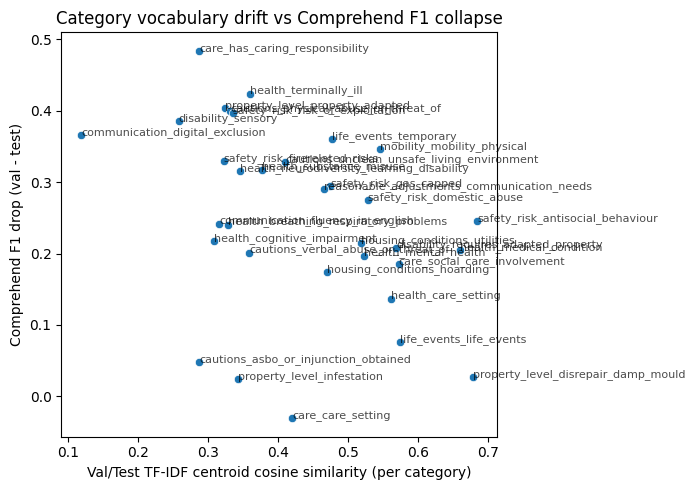

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=merged, x="val_test_sim", y="f1_drop")
for _, row in merged.iterrows():
    plt.annotate(row["category"], (row["val_test_sim"], row["f1_drop"]), fontsize=8, alpha=0.7)
plt.xlabel("Val/Test TF-IDF centroid cosine similarity (per category)")
plt.ylabel("Comprehend F1 drop (val - test)")
plt.title("Category vocabulary drift vs Comprehend F1 collapse")
plt.tight_layout()
plt.show()


 ## 7. Misclassified-span clustering (optional follow-up)



 If the correlation above is suggestive, the next step is checking whether

 Comprehend's misclassified test spans disproportionately fall in notes

 with low similarity to their val-set counterparts — i.e. whether the

 errors themselves cluster on the drifted vocabulary, not just the

 category-level aggregate.

In [ ]:
# Expects a DataFrame of Comprehend's test predictions with a `correct` bool column
# and `note_id` to join back to test_df's text.
#
# comprehend_preds = pd.read_json("comprehend_test_predictions.jsonl", lines=True)
# preds_with_text = comprehend_preds.merge(test_df[["note_id", "text"]], on="note_id")
# preds_tfidf = vectorizer_val.transform(preds_with_text["text"])
#
# For each note, compute similarity to its category's val centroid, then
# compare the distribution of that similarity for correct vs incorrect predictions
# (e.g. via a boxplot or Mann-Whitney U test). Lower similarity among incorrect
# predictions would support the drift theory as a mechanism, not just a correlation.